In [1]:
# 1: Bib

import time
start_time = time.perf_counter()

import os
import re
import json
import csv
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)
from datetime import datetime


In [2]:

# 2: Dataset Class: transfer CSV in PyTorch.
class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None, dataset_size=None, read_all4once=True):

        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.dataset_size = dataset_size if dataset_size is not None else len(self.df)
        self.read_all4once = read_all4once

        if self.read_all4once:
            img = Image.new("RGB", (500, 300))  # any size
            out = transform(img)
            self.images = torch.zeros([self.dataset_size] + list(out.shape))
            self.targets = torch.zeros(self.dataset_size, 2)

        for idx in tqdm(range(self.dataset_size)):

            row = self.df.iloc[idx]

            image = Image.open(
                row["image_name"]
            ).convert("RGB")

            self.targets[idx] = torch.tensor(
                [row["x"], row["y"]],
                dtype=torch.float32
            )

            if self.transform:
                self.images[idx] = self.transform(image)
            else:
                self.images[idx] = image

    def __len__(self):

        return self.dataset_size

    def __getitem__(self, idx):

        return self.images[idx], self.targets[idx]

In [3]:

# 5: func-Diagonal-Error:
def diagonal_errors(model, loader, device):
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    mae = mean_absolute_error(targets_all, predictions)
    
    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [4]:
# 6: CSV laden
df = pd.read_csv("dataset/norm_labels.csv")
df.head()
# check:
# print(df.shape)

,image_name,x,y,subject_ID,screen_w,screen_h
0,dataset/images/00002/00002/frames/00000.jpg,0.500000,0.500000,2,320,568
1,dataset/images/00002/00002/frames/00001.jpg,0.500000,0.500000,2,320,568
2,dataset/images/00002/00002/frames/00002.jpg,0.500000,0.500000,2,320,568
3,dataset/images/00002/00002/frames/00003.jpg,0.500000,0.500000,2,320,568
4,dataset/images/00002/00002/frames/00004.jpg,0.873929,0.114375,2,320,568


In [7]:
# 7: check a image
# row = df.iloc[0]
# img = Image.open(row["image_name"])
# plt.imshow(img)
# plt.show()
# print(row["x"], row["y"])

In [5]:
# 8: DataLoader
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1,1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset:

# def_dataset_size = [10000, 2000]
def_dataset_size = [1000, 200]

def_dataset = 'norm_subject'

train_dataset = GazeDataset(
    "./splits/norm_subject_train.csv",
    transform, dataset_size=def_dataset_size[0],
)

test_dataset = GazeDataset(
    "./splits/norm_subject_test.csv",
    transform, dataset_size=def_dataset_size[1],
)



# def_dataset = 'norm_random'

# train_dataset = GazeDataset(
#     "./splits/norm_random_train.csv",
#     transform, dataset_size=def_dataset_size[0],
# )

# test_dataset = GazeDataset(
#     "./splits/norm_random_test.csv",
#     transform, dataset_size=def_dataset_size[1],
# )



# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 60.65it/s]


In [6]:
## Test:
# datasets_file = ["./dataset/labels.csv", "./dataset/norm_labels.csv"]
# d = datasets_file[0]
# print(f"{d}:")
# df = pd.read_csv(d)
# print(df[["x", "y"]].describe())

# d = datasets_file[1]
# print(f"{d}:")
# df = pd.read_csv(d)
# print(df[["x", "y"]].describe())



# print(f" len(train_dataset): {len(train_dataset)}")
# print(f" len(test_dataset):  {len(test_dataset)}")



In [7]:
# 9: ResNet18 (Pretrainiertes Modell):
# Load:
model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        128
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        128,
        2
    ),
    nn.ReLU()
)

In [8]:
# 10: GPU
# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# print(device)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [9]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()
learning_rate = 1e-5

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True

for param in model.fc.parameters():
    param.requires_grad=True


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)

# Optimizer:
# optimizer = torch.optim.Adam(
#     # model.parameters(),
#     model.fc.parameters(),
#     lr=1e-4
# )

In [10]:
# 12: Training
epochs = 12
# epochs = 2

model_output = './models'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

best_error = None
diag_test_error, diag_train_error = [], []

train_start = time.perf_counter()

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()
    
    print(f"\ntrain_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\ntest_error:")
    test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
    diag_test_error.append(np.round(test_diag_pct, 4))


    if best_error is None or test_rmse < best_error:
        best_error = test_rmse
        torch.save(model.state_dict(), "./models/best_model_optimal.path")

    epoch_end = time.perf_counter()

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"test_diag_error={test_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% \n"
    )

    torch.save(model.state_dict(), "./models/last_model_optimal.path")


train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

# print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
# print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [02:01<00:00,  7.58s/it, loss=0.111]



train_error:
MAE : 0.3619 	 RMSE: 0.4445 
Diagonal-Error %: 31.4318 %

test_error:
MAE : 0.3754 	 RMSE: 0.4626 
Diagonal-Error %: 32.7124 %

[01:53:26] Epoch 1: 223.38 Sekunden | Running_loss: 0.109 | test_diag_error=32.7124% | train_diag_error=31.4318% 



Epoch 2: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:57<00:00,  7.37s/it, loss=0.0562]



train_error:
MAE : 0.2822 	 RMSE: 0.3557 
Diagonal-Error %: 25.1487 %

test_error:
MAE : 0.3113 	 RMSE: 0.3929 
Diagonal-Error %: 27.7827 %

[01:56:32] Epoch 2: 186.65 Sekunden | Running_loss: 0.075 | test_diag_error=27.7827% | train_diag_error=25.1487% 



Epoch 3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:50<00:00,  6.90s/it, loss=0.0374]


...


train_error:
MAE : 0.1843 	 RMSE: 0.2257 
Diagonal-Error %: 15.9570 %

test_error:
MAE : 0.2484 	 RMSE: 0.3006 
Diagonal-Error %: 21.2550 %

[02:22:32] Epoch 10: 131.25 Sekunden | Running_loss: 0.029 | test_diag_error=21.2550% | train_diag_error=15.9570% 



Epoch 11: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:59<00:00,  3.70s/it, loss=0.0247]



train_error:
MAE : 0.1787 	 RMSE: 0.2198 
Diagonal-Error %: 15.5426 %

test_error:
MAE : 0.2499 	 RMSE: 0.3020 
Diagonal-Error %: 21.3542 %

[02:24:23] Epoch 11: 111.78 Sekunden | Running_loss: 0.028 | test_diag_error=21.3542% | train_diag_error=15.5426% 



Epoch 12: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:02<00:00,  3.90s/it, loss=0.0262]



train_error:
MAE : 0.1744 	 RMSE: 0.2139 
Diagonal-Error %: 15.1274 %

test_error:
MAE : 0.2516 	 RMSE: 0.3045 
Diagonal-Error %: 21.5283 %

[02:26:23] Epoch 12: 119.86 Sekunden | Running_loss: 0.027 | test_diag_error=21.5283% | train_diag_error=15.1274% 


totll running-tiems (s): 2201.35 Sekunden
totll running-tiems (min): 36.69 Minuten


Gesamte Laufzeit: 2271.87 Sekunden
Gesamte Laufzeit: 37.86 Minuten





 Diagonal-Train-Error: [31.4318 25.1487 21.8107 19.1716 17.9527 17.5563 17.1683 16.7683 16.3563
 15.957  15.5426 15.1274]

 Diagonal-Test-Error: [32.7124 27.7827 23.1685 21.1838 20.8719 20.9281 21.0917 21.0767 21.1891
 21.255  21.3542 21.5283]


 Diagonal-Train-Error-Max: 31.4318 	 Diagonal-Train-Error-Min: 15.1274	
 Diagonal-Test-Error-Max: 32.7124	 Diagonal-Test-Error-Min: 20.8719	 


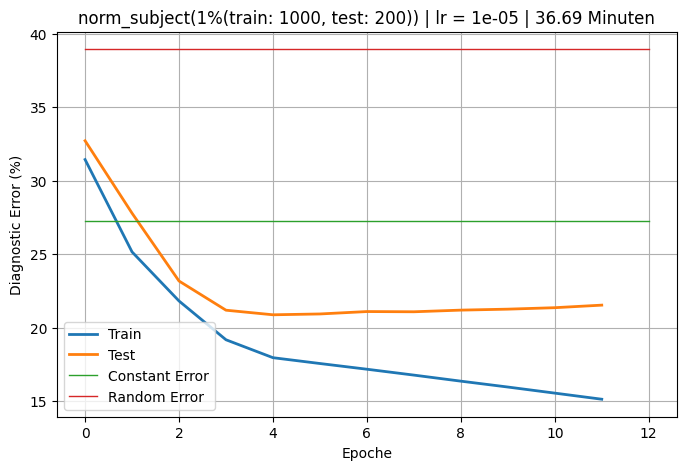

In [11]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_test_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_test_error)}\t Diagonal-Test-Error-Min: {np.min(diag_test_error)}\t ")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")


# Curven:

epochs = range(0, len(diag_test_error) + 1)
# epochs = range(1, len(diag_train_error) + 1)

plt.figure(figsize=(8, 5))

plt.plot(diag_train_error, label="Train", linewidth=2)
plt.plot(diag_test_error, label="Test", linewidth=2)


plt.plot(epochs, [27.245] * len(epochs),
         label="Constant Error", linewidth=1)

plt.plot(epochs, [38.939] * len(epochs),
         label="Random Error", linewidth=1)


plt.title(f"{def_dataset}(1%(train: {def_dataset_size[0]}, test: {def_dataset_size[1]})) |" 
          f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten"
)

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")
plt.grid(True)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/diag_error_{def_dataset}_{learning_rate}_{def_dataset_size[0]}_{def_dataset_size[1]}_a.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

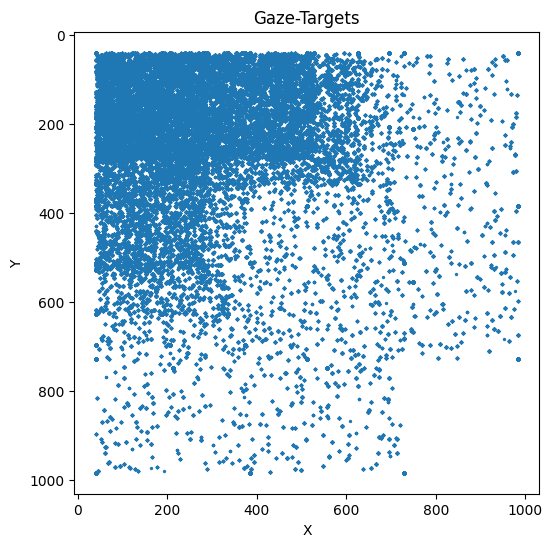



X_min: 0.0390625	 X_max: 1.0
Y_min: 0.0390625	 Y_max: 1.0 




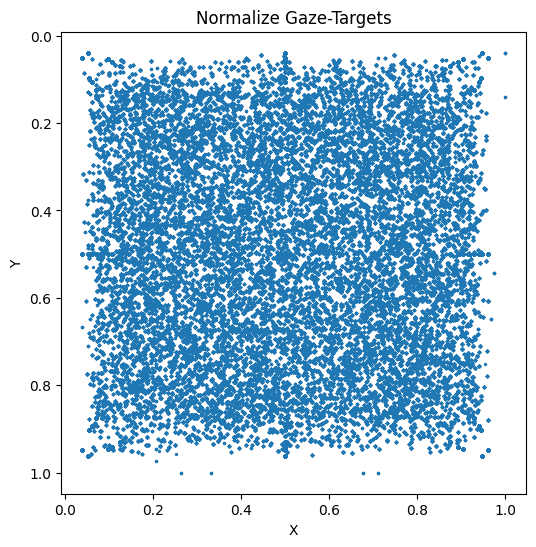

In [30]:
# PLOT:
# images_dir = "./datasets/images/"
labels_file = "./dataset/labels.csv"

df = pd.read_csv(labels_file)

# print(df.head())
# print("Anzahl Samples:", len(df))

x = df["x"]
y = df["y"]

# print(f"X_min: {np.min(x)}\t X_max: {np.max(x)}")
# print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)}")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()





# Normalize:

norm_labels_file = './dataset/norm_labels.csv'

df2 = pd.read_csv(norm_labels_file)

x = df2["x"]
y = df2["y"]

print(f"\n\nX_min: {np.min(x)}\t X_max: {np.max(x)}")
print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)} \n\n")
"""
df = pd.read_csv("./dataset/norm_labels.csv")

errors = df[(df["x_norm"] > 1) | (df["y_norm"] > 1)]

print(errors)
"""

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Normalize Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()

In [11]:
# Normalization: 

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: -------------------------------
# -------------------------------------------------------------------

print("\nNormalization: \n")
norm_labels_file = './dataset/norm_labels.csv'
df2 = pd.read_csv(norm_labels_file)



x_true = df2["x"].values
y_true = df2["y"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)

# x_const = 0.5
# y_const = 0.5

print(f"x_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))
const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nKonstant Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
# print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


# -------------------------------------------------------------------
# ---------------------- Random-Error -------------------------------
# -------------------------------------------------------------------

x = df2["x"]
y = df2["y"]
x_max = np.max(x)
x_min = np.min(x)
y_max = np.max(y)
y_min = np.min(y)

# x_max = 1.0
# y_max = 1.0


pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

random_errors = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

mae = np.mean(random_errors)
rmse = np.sqrt(np.mean(random_errors ** 2))
random_error_pct = 100 * np.round(rmse, 5)
random_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Random_Mean_Absolute_Error: {mae}")
print(f"Random_Mean_Squared_Error: {rmse}")
# print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} % \n\n")


Normalization: 

x_const: 0.5018271047520313
y_const: 0.5004797436472681

Konstant Baseline:

Constant_Mean_Absolute_Error: 0.35649399675432236
Constant_Mean_Squared_Error: 0.3852981815765823
Constant_Diagonal-Error %: 27.245 %

Random Baseline:

Random_Mean_Absolute_Error: 0.4968523632829308
Random_Mean_Squared_Error: 0.5507601350828084
Random_Diagonal-Error %: 38.945 % 




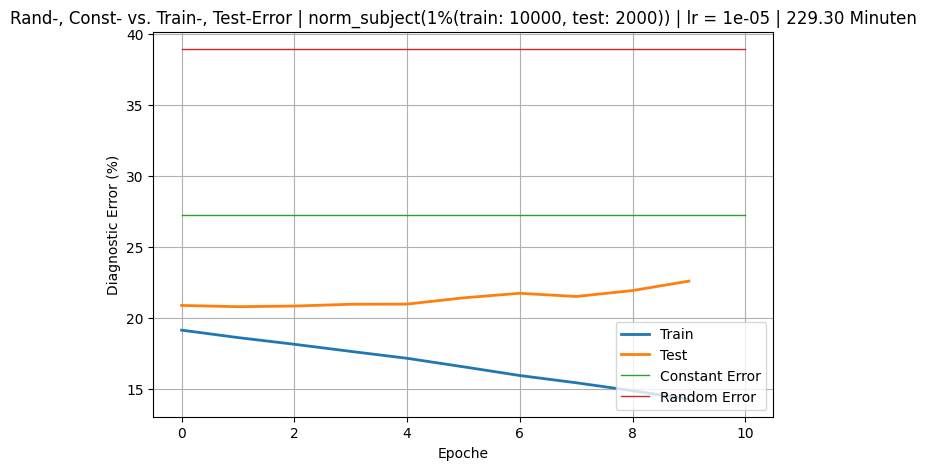

In [12]:
# Curven:

epochs = range(0, len(diag_test_error) + 1)
# epochs = range(1, 11)
plt.figure(figsize=(8, 5))

plt.plot(diag_train_error, label="Train", linewidth=2)
plt.plot(diag_test_error, label="Test", linewidth=2)


plt.plot(epochs, [const_diagonal_error_pct] * len(epochs),
         label="Constant Error", linewidth=1)

plt.plot(epochs, [random_diagonal_error_pct] * len(epochs),
         label="Random Error", linewidth=1)

# plt.plot(epochs, diag_test_error, marker='o', linewidth=2)

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")
plt.title(f"Rand-, Const- vs. Train-, Test-Error | "
          f"{def_dataset}(1%(train: {def_dataset_size[0]}, test: {def_dataset_size[1]})) |" 
          f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten"
)

plt.grid(True)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/diag_error_{def_dataset}_{learning_rate}_{def_dataset_size[0]}_{def_dataset_size[1]}_b.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

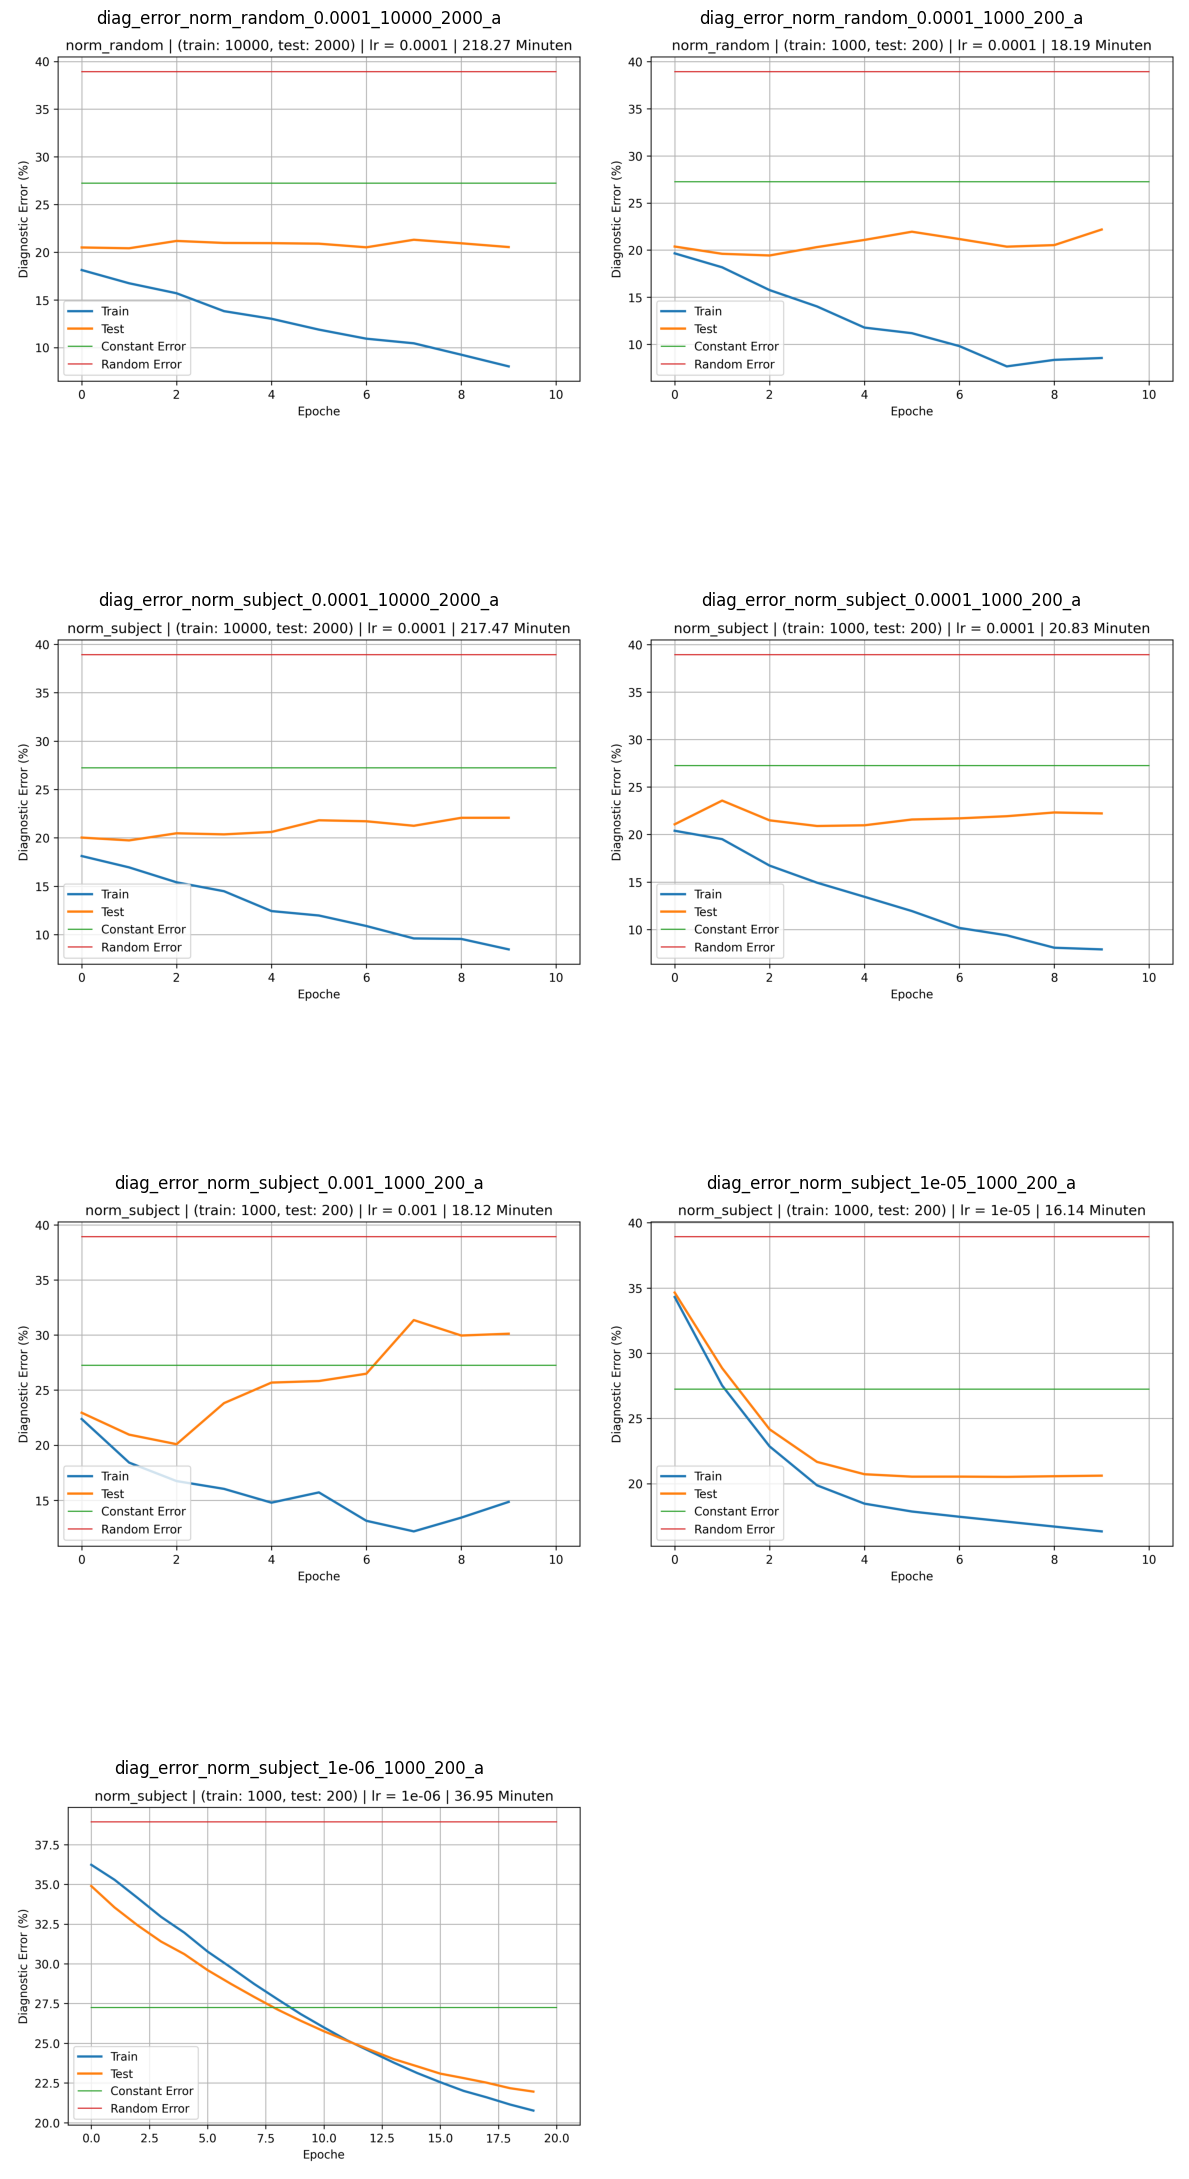

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

result_path = Path("./results")

images = sorted(result_path.glob("*.png"))

cols = 2
rows = (len(images) + cols - 1) // cols

plt.figure(figsize=(12, 6 * rows))

for i, img_path in enumerate(images):

    img = mpimg.imread(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.stem)

plt.tight_layout()
plt.show()

                                        image_name    x_norm    y_norm  \
99106  dataset/images/00258/00258/frames/00009.jpg  0.262721  1.007969   
99107  dataset/images/00258/00258/frames/00010.jpg  0.262721  1.007969   
99108  dataset/images/00258/00258/frames/00011.jpg  0.262721  1.007969   
99115  dataset/images/00258/00258/frames/00018.jpg  0.331600  1.217468   
99116  dataset/images/00258/00258/frames/00019.jpg  0.331600  1.217468   
99117  dataset/images/00258/00258/frames/00020.jpg  0.331600  1.217468   
99124  dataset/images/00258/00258/frames/00027.jpg  1.281250  0.039062   
99125  dataset/images/00258/00258/frames/00028.jpg  1.281250  0.039062   
99126  dataset/images/00258/00258/frames/00029.jpg  1.281250  0.039062   
99161  dataset/images/00258/00258/frames/00064.jpg  0.710938  1.281250   
99162  dataset/images/00258/00258/frames/00065.jpg  0.710938  1.281250   
99163  dataset/images/00258/00258/frames/00066.jpg  0.710938  1.281250   
99172  dataset/images/00258/00258/fram

In [ ]:
# Inference
model.load_state_dict(
    torch.load(
        "gaze_model.pth"
    )
)

model.eval()

In [ ]:
predictions = []
targets_all = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)
        preds = model(images)

        predictions.append(
            preds.cpu()
        )

        targets_all.append(
            targets
        )


predictions = torch.cat(
    predictions
)

targets_all = torch.cat(
    targets_all
)
